In [3]:
using LinearAlgebra
using ForwardDiff
using Plots

In [4]:

function f(x)
    return x.^4 + x.^3 - x.^2 -x
end

f (generic function with 1 method)

In [5]:
function ∇f(x) #gradient of f(x)
    return 4.0*x.^3 + 3.0*x.^2 - 2.0*x - 1.0
end

∇f (generic function with 1 method)

In [6]:
function ∇2f(x)
    return 12.0x.^2 + 6.0*x - 2.0
end

∇2f (generic function with 1 method)

In [7]:
x = LinRange(-1.75, 1.25,1000)

1000-element LinRange{Float64, Int64}:
 -1.75, -1.747, -1.74399, -1.74099, …, 1.24099, 1.24399, 1.247, 1.25

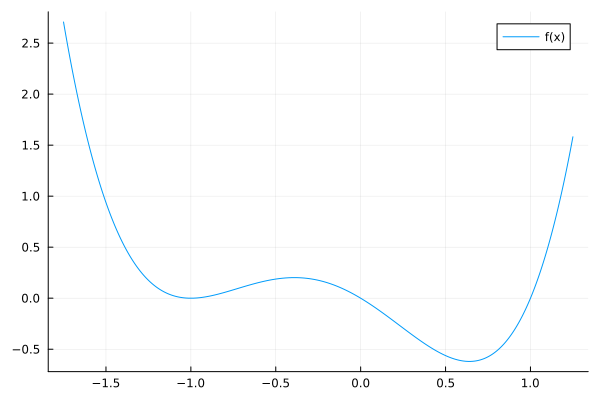

In [8]:
p = plot(x,f(x), label = "f(x)")

In [9]:
function newton_step(x0)
    xn = x0 -∇2f(x0)\∇f(x0)
    return xn
end

newton_step (generic function with 1 method)

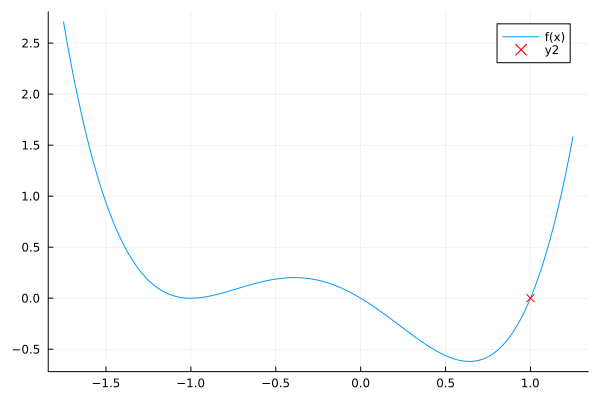

In [10]:
xguess = [1.0]
plot(x,f(x), label = "f(x)")
scatter!(xguess, f(xguess), marker=:x, color = :red)

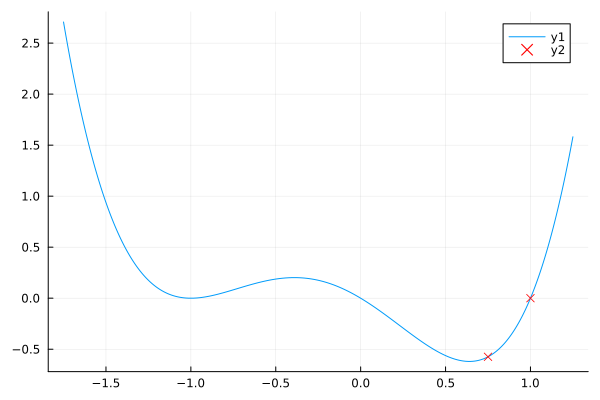

In [11]:
xnew = newton_step(xguess[end])
xguess = vcat(xguess, xnew)
plot(x, f(x))
scatter!(xguess, f(xguess), marker=:x, color=:red)

In [12]:
∇2f(0.0)

-2.0

In [13]:
function regularized_newton_step(x0)
    β = 1.0
    H = ∇2f(x0)
    while !isposdef(H)
        H = H + β*I
    end
    xn = x0 - H\∇f(x0)
    return xn
end

regularized_newton_step (generic function with 1 method)

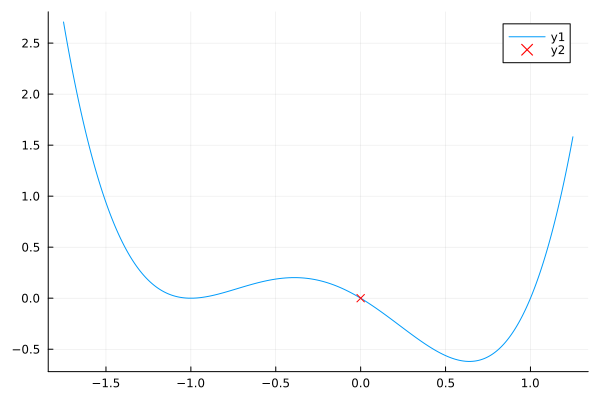

In [14]:
xguess = [0.0]
plot(x, f(x))
scatter!(xguess, f(xguess), marker=:x, color=:red)

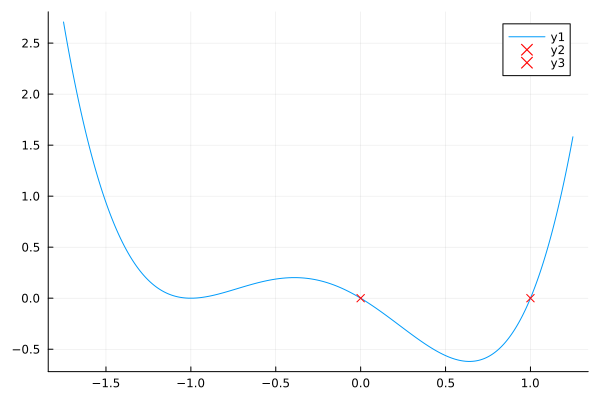

In [15]:
xnew = regularized_newton_step(xguess[end])
xguess = [xguess xnew]
plot(x, f(x))
scatter!(xguess, f(xguess), marker=:x, color=:red)

In [16]:

function backtracking_regularized_newton_step(x0)
    b = 0.1
    c = 0.5
    β = 1.0
    H = ∇2f(x0)
    while !isposdef(H)
        H = H + β*I
    end
    Δx = -H\∇f(x0)
    
    α = 1.0
    while f(x0 + α*Δx) > f(x0) + b*α*∇f(x0)*Δx
        α = c*α
    end
    print(α)
    xn = x0 + α*Δx
    return xn
end

backtracking_regularized_newton_step (generic function with 1 method)

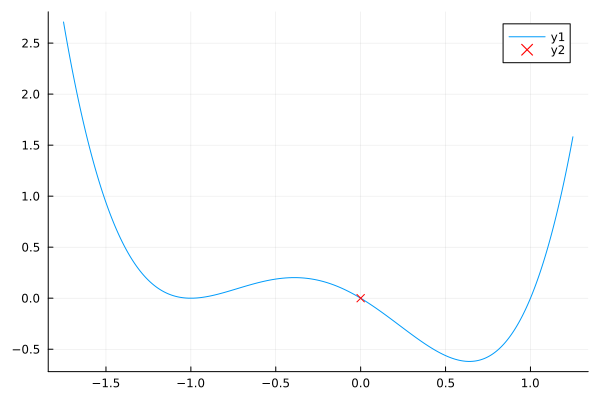

In [17]:
xguess = [0.0]
plot(x, f(x))
scatter!(xguess, f(xguess), marker=:x, color=:red)

0.5

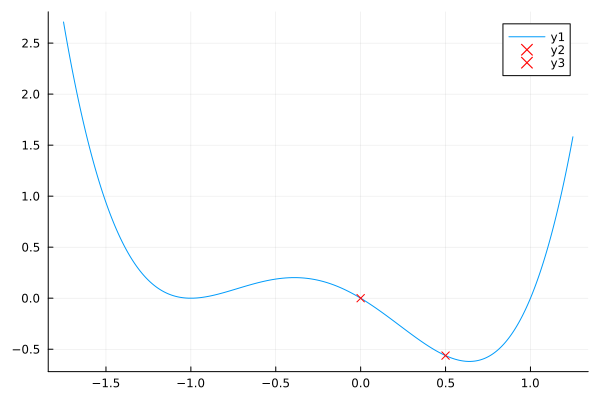

In [18]:
xnew = backtracking_regularized_newton_step(xguess[end])
xguess = [xguess xnew]
plot(x, f(x))
scatter!(xguess, f(xguess), marker=:x, color=:red)